# Reddit AI Sentiment Analysis

This project analyzes Reddit discussions about artificial intelligence tools such as ChatGPT. The goal is to explore how different Reddit communities discuss AI and whether their attitudes tend to be positive, neutral, or negative.

The analysis focuses on several subreddits, including:

- r/ChatGPT
- r/Futurology
- r/technology
- r/dataisbeautiful

We perform exploratory data analysis (EDA), keyword analysis, and sentiment analysis to better understand the tone and themes of these discussions.

## Table of Contents

1. Dataset  
2. Data Cleaning and Preprocessing  
3. Exploratory Data Analysis  
4. Keyword Preparation  
5. Word Cloud Visualization  
6. Keyword Analysis by Subreddit  
7. Sentiment Analysis  
8. Sentiment Distribution by Subreddit  
9. Example Positive Comments  
10. Average Sentiment by Subreddit  
11. Conclusion

In [274]:
# basic setup
import os
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gabrielroisenbergrodrigues/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Dataset Description

The dataset contains Reddit comments discussing AI-related topics.  
Each record includes the comment text and the subreddit where it was posted.

Main columns used in this analysis:

- `comment_body` — the text of the Reddit comment  
- `subreddit` — the subreddit where the comment appeared

In [275]:
# Load the dataset
df = pd.read_csv("../data/raw/chatgpt-reddit-comments.csv")

df.head()

,Unnamed: 0,comment_id,comment_parent_id,comment_body,subreddit
0,0,iztdxuh,t3_zj2aeu,"I've been shocked for days now, I don't need c...",r/ChatGPT
1,1,iztn0q0,t3_zj2aeu,\n\nI am so angry right now. I just wasted my...,r/ChatGPT
2,2,izudrph,t3_zj2aeu,chatgpt karma whoring is here folks! just when...,r/ChatGPT
3,3,iztfhtb,t3_zj2aeu,"Worked on me, ngl.",r/ChatGPT
4,4,izu2as9,t3_zj2aeu,"Certified 10/10, must-see moment. It really di...",r/ChatGPT


In [276]:
df.shape

(52416, 5)

In [277]:
# inspect the structure
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Unnamed: 0         52413 non-null  str  
 1   comment_id         52415 non-null  str  
 2   comment_parent_id  52415 non-null  str  
 3   comment_body       52415 non-null  str  
 4   subreddit          52415 non-null  str  
dtypes: str(5)
memory usage: 2.0 MB


In [278]:
df.columns

Index(['Unnamed: 0', 'comment_id', 'comment_parent_id', 'comment_body',
       'subreddit'],
      dtype='str')

In [279]:
# check missing values
df.isna().sum()

Unnamed: 0           3
comment_id           1
comment_parent_id    1
comment_body         1
subreddit            1
dtype: int64

## Data Cleaning and Preprocessing

Before analyzing the dataset, we perform several cleaning steps:

- Remove unnecessary columns
- Handle missing values
- Normalize text
- Remove stopwords
- Prepare text for keyword analysis

In [280]:
# Remove unnecessary columns
df = df.drop(columns=['Unnamed: 0'])
df.columns

Index(['comment_id', 'comment_parent_id', 'comment_body', 'subreddit'], dtype='str')

In [281]:
# Remove missing values
df = df.dropna()
df.isna().sum()

comment_id           0
comment_parent_id    0
comment_body         0
subreddit            0
dtype: int64

In [282]:
# text processing
df["text_clean"] = df["comment_body"].astype(str).str.lower()

df["text_clean"] = df["text_clean"].str.replace(r"http\S+", "", regex=True)

df["text_clean"] = df["text_clean"].str.replace(r"[^\w\s]", "", regex=True)

df["text_clean"] = df["text_clean"].str.replace(r"\s+", " ", regex=True)

df[["comment_body", "text_clean"]].head()

,comment_body,text_clean
0,"I've been shocked for days now, I don't need c...",ive been shocked for days now i dont need clic...
1,\n\nI am so angry right now. I just wasted my...,i am so angry right now i just wasted my time...
2,chatgpt karma whoring is here folks! just when...,chatgpt karma whoring is here folks just when ...
3,"Worked on me, ngl.",worked on me ngl
4,"Certified 10/10, must-see moment. It really di...",certified 1010 mustsee moment it really did sh...


In [283]:
# count how many comments per subreddit
df["subreddit"].value_counts()

subreddit
r/ChatGPT            29711
r/technology         16672
r/Futurology          5009
r/dataisbeautiful     1020
subreddit                3
Name: count, dtype: int64

In [284]:
# remove header row repeated inside the file
df = df[df["subreddit"] != "subreddit"]

df["subreddit"].value_counts()

subreddit
r/ChatGPT            29711
r/technology         16672
r/Futurology          5009
r/dataisbeautiful     1020
Name: count, dtype: int64

## Exploratory Data Analysis

We begin by exploring the most common words used in Reddit discussions about AI.
This helps reveal the main topics and themes discussed by users.

To understand how the dataset is distributed, we first examine how many comments come from each subreddit.

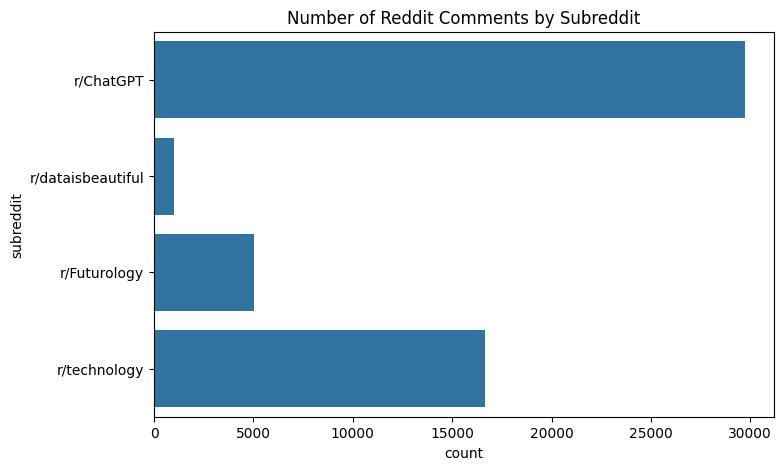

In [285]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, y="subreddit")

plt.title("Number of Reddit Comments by Subreddit")
plt.show()

**Observation**: The dataset is dominated by comments from r/ChatGPT and r/technology, suggesting that these communities are more active in discussions about AI tools.

## Keyword Preparation

To analyze the themes present in Reddit discussions, we first preprocess the comment text to extract meaningful keywords. Natural language data typically contains many common words (known as *stopwords*) that appear frequently but do not contribute useful information for topic analysis.

In this step, we remove standard English stopwords and define additional custom stopwords specific to our dataset. This preprocessing allows us to focus on the most informative terms that reflect how users discuss AI technologies across different Reddit communities.

In [286]:
df.to_csv("../data/processed/chatgpt_sentiment.csv", index=False)

In [287]:
# Create a set of English stopwords using NLTK.
# Stopwords are very common words (e.g., "the", "and", "is") that usually do not
# provide meaningful information for keyword analysis.
stop_words = set(stopwords.words("english"))


# Remove stopwords from the cleaned text.
# For each comment, we split the text into individual words and keep only the
# words that are not part of the stopword list.
df["text_no_stopwords"] = df["text_clean"].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in stop_words
    )
)


# Combine all cleaned comments into a single list of words.
# This allows us to analyze the overall frequency of keywords across the dataset.
all_words = " ".join(df["text_no_stopwords"]).split()


# Count how many times each word appears in the dataset using Counter.
# Counter returns a dictionary-like structure with word frequencies.
word_counts = Counter(all_words)


# Display the 20 most common words in the dataset.
# This helps identify the dominant themes discussed in the comments.
word_counts.most_common(20)

[('ai', 9751),
 ('like', 9513),
 ('chatgpt', 9430),
 ('people', 7085),
 ('would', 6827),
 ('dont', 5750),
 ('im', 5222),
 ('use', 5182),
 ('get', 5049),
 ('think', 4959),
 ('one', 4617),
 ('even', 4331),
 ('make', 4255),
 ('time', 4204),
 ('know', 3952),
 ('work', 3832),
 ('way', 3827),
 ('could', 3805),
 ('good', 3732),
 ('thats', 3727)]

In [288]:
# Define a set of custom stopwords specific to our dataset.
# These are words that appear very frequently in Reddit discussions but
# do not provide useful insight into the themes of the conversation.
# For example, conversational filler words ("like", "really") or very common
# discussion terms ("people", "think") can dominate the keyword counts.
custom_stopwords = {
    "im","dont","thats","like","would","one","even","get",
    "make","time","know","think","people","could","also",
    "something","really","well","things","going","much",
    "want","see","need","way","good","chatgpt"
}


# Combine the standard English stopwords with our custom stopwords.
# This creates a more comprehensive list of words to remove when extracting
# meaningful keywords from the text.
all_stopwords = stop_words.union(custom_stopwords)


# Recreate the filtered text column using the expanded stopword list.
# The resulting column (text_keywords) contains the cleaned text with both
# standard and custom stopwords removed, leaving mostly informative keywords.
df["text_keywords"] = df["text_clean"].apply(
    lambda text: " ".join(
        word for word in text.split() if word not in all_stopwords
    )
)


# Combine all cleaned keyword text into a single list of words.
# This allows us to analyze overall keyword frequencies across the dataset.
words = " ".join(df["text_keywords"]).split()


# Count how often each keyword appears in the dataset.
word_counts = Counter(words)


# Display the 20 most common keywords after applying the expanded stopword filtering.
word_counts.most_common(20)

[('ai', 9751),
 ('use', 5182),
 ('work', 3832),
 ('google', 3499),
 ('write', 3201),
 ('using', 2942),
 ('cant', 2657),
 ('still', 2576),
 ('better', 2531),
 ('doesnt', 2510),
 ('used', 2477),
 ('actually', 2442),
 ('youre', 2437),
 ('human', 2402),
 ('right', 2388),
 ('thing', 2378),
 ('ask', 2319),
 ('say', 2259),
 ('answer', 2207),
 ('give', 2107)]

**Observation**: After removing both standard and custom stopwords, the most frequent keywords better reflect the themes discussed in Reddit conversations about AI, such as usage, work, writing, and search technologies.

## Sentiment Analysis

To understand the emotional tone of Reddit discussions, we use the VADER sentiment analyzer from NLTK.

This model is designed specifically for social media text and returns a compound sentiment score ranging from:

- -1 (very negative)
- 0 (neutral)
- +1 (very positive)

In [289]:
# Calculate sentiment scores using VADER
# create sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# compute compound score
df["sentiment_score"] = df["text_clean"].apply(
    lambda text: analyzer.polarity_scores(text)["compound"]
)

In [290]:
# define sentiment categories
def label_sentiment(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

In [291]:
# apply sentiment categories
df["sentiment"] = df["sentiment_score"].apply(label_sentiment)

# inspect the results
df[["text_clean", "sentiment_score", "sentiment"]].head()

,text_clean,sentiment_score,sentiment
0,ive been shocked for days now i dont need clic...,-0.3182,negative
1,i am so angry right now i just wasted my time...,-0.9714,negative
2,chatgpt karma whoring is here folks just when ...,-0.7730,negative
3,worked on me ngl,0.0000,neutral
4,certified 1010 mustsee moment it really did sh...,-0.4364,negative


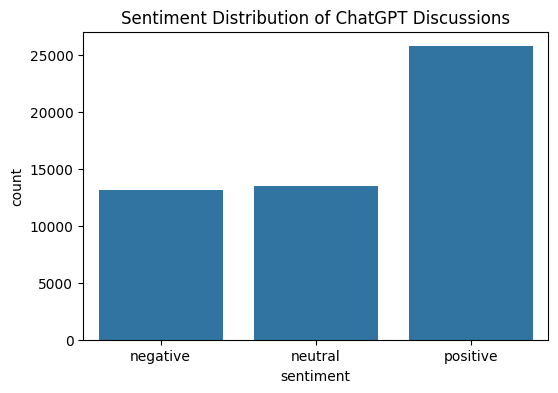

In [292]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution of ChatGPT Discussions")
plt.show()

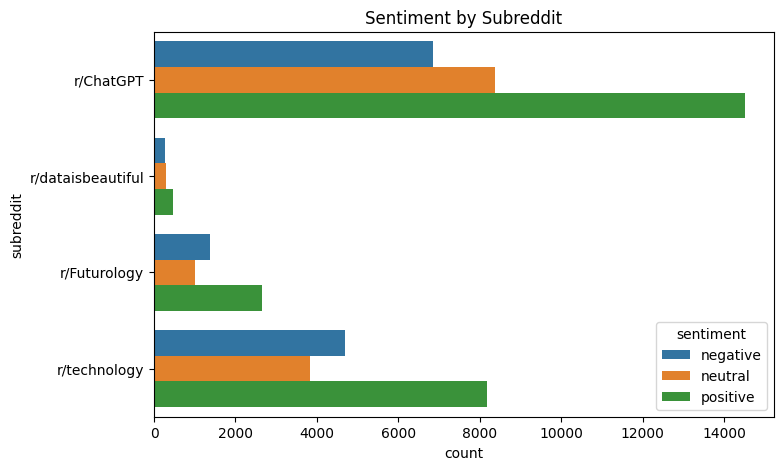

In [293]:
# check sentiment by subreddit
plt.figure(figsize=(8,5))

sns.countplot(data=df, y="subreddit", hue="sentiment")

plt.title("Sentiment by Subreddit")
plt.show()

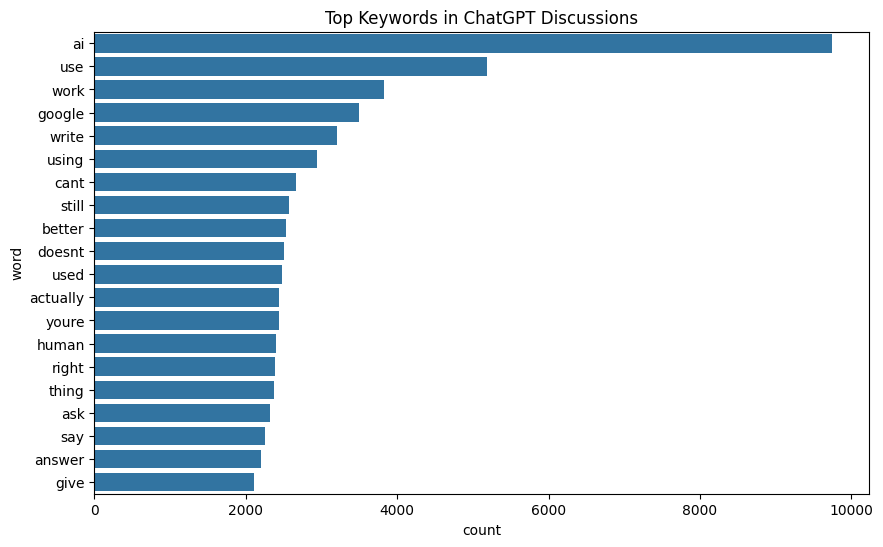

In [294]:
# Convert to a dataframe (for plotting)
top_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

# Visualization of top words
plt.figure(figsize=(10,6))

sns.barplot(data=top_words, x="count", y="word")

plt.title("Top Keywords in ChatGPT Discussions")

plt.show()

## Word Cloud Visualization

A word cloud helps visualize the most frequent terms appearing in Reddit comments.
Larger words represent terms that appear more often in the dataset.

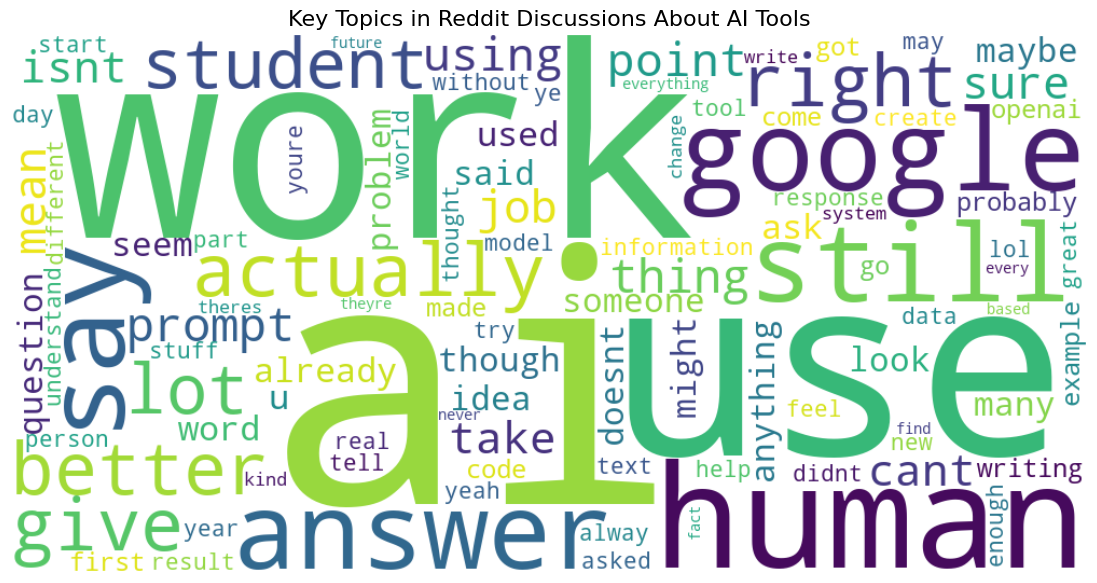

In [295]:
text = " ".join(df["text_keywords"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis",
    max_words=100
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Key Topics in Reddit Discussions About AI Tools", fontsize=16)

plt.show()

**Observation**: The word cloud highlights the most frequent keywords in Reddit discussions about AI tools. Terms such as AI, Google, writing, usage, and interaction verbs like ask and answer appear prominently, indicating that discussions often revolve around practical applications of AI systems, comparisons with other technologies, and how users interact with these tools.

## Keyword Analysis by Subreddit

Different Reddit communities may focus on different aspects of AI.  
To explore these differences, we analyze the most common keywords in each subreddit.

In [296]:
# Create a sentiment table by subreddit
sentiment_by_sub = pd.crosstab(df["subreddit"], df["sentiment"])

sentiment_by_sub

sentiment,negative,neutral,positive
subreddit,,,
r/ChatGPT,6841,8372,14498
r/Futurology,1372,997,2640
r/dataisbeautiful,258,286,476
r/technology,4681,3820,8171


In [297]:
#  Convert to percentages
sentiment_percent = sentiment_by_sub.div(sentiment_by_sub.sum(axis=1), axis=0).round(2)* 100

sentiment_percent

sentiment,negative,neutral,positive
subreddit,,,
r/ChatGPT,23.0,28.0,49.0
r/Futurology,27.0,20.0,53.0
r/dataisbeautiful,25.0,28.0,47.0
r/technology,28.0,23.0,49.0


## Sentiment Distribution by Subreddit

The following visualization shows the proportion of positive, neutral, and negative comments in each subreddit.

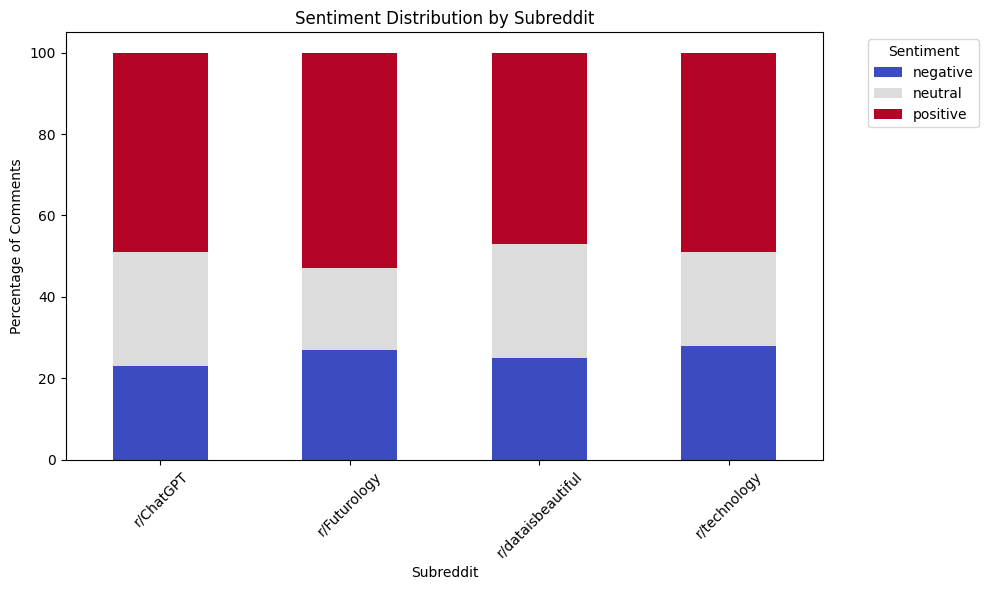

In [298]:
#  Create a stacked bar chart
sentiment_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="coolwarm"
)

plt.title("Sentiment Distribution by Subreddit")

plt.ylabel("Percentage of Comments")

plt.xlabel("Subreddit")

plt.xticks(rotation=45) 

plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()  

plt.show()

**r/ChatGPT**: The r/ChatGPT community shows a relatively positive attitude toward AI tools, which is expected since users in this subreddit are already interested in discussing and experimenting with ChatGPT.

**r/Futurology**: Discussions in r/Futurology appear more polarized, with a higher proportion of critical comments. This may reflect broader societal concerns about the long-term impact of AI technologies.

**r/technology**: The broader technology community appears more skeptical compared to the dedicated ChatGPT subreddit, suggesting more critical evaluation of AI capabilities and limitations.

**General takeaway**: Most comments across all subreddits fall into the positive or neutral categories, suggesting that discussions about AI tend to be more optimistic than negative.

In [299]:
# Create function to extract top words
def top_words(text_series, n=10):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

In [300]:
rows = []

for sub in df["subreddit"].unique():
    
    words = top_words(df[df["subreddit"] == sub]["text_keywords"], 10)
    
    for word, count in words:
        rows.append({
            "subreddit": sub,
            "word": word,
            "count": count
        })

keywords_df = pd.DataFrame(rows)

keywords_df.head()

,subreddit,word,count
0,r/ChatGPT,ai,4840
1,r/ChatGPT,use,2768
2,r/ChatGPT,write,1648
3,r/ChatGPT,work,1622
4,r/ChatGPT,prompt,1584


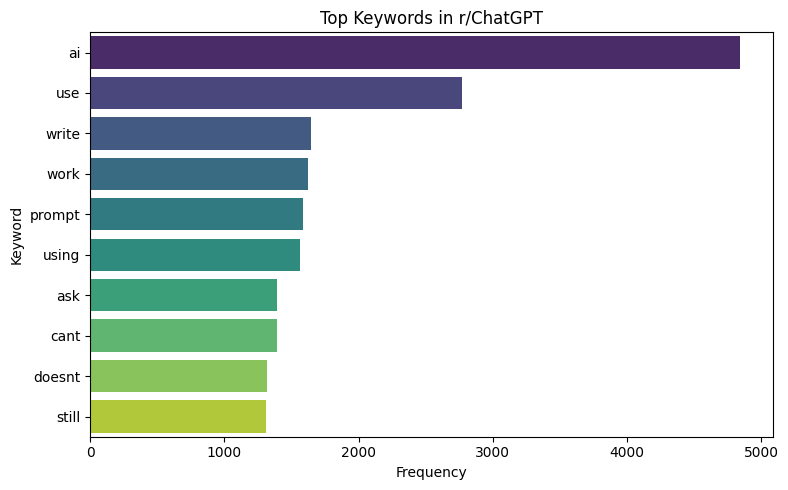

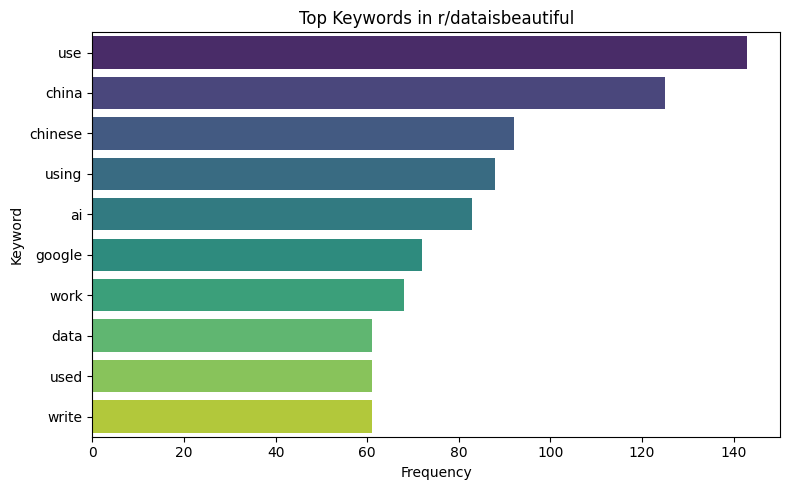

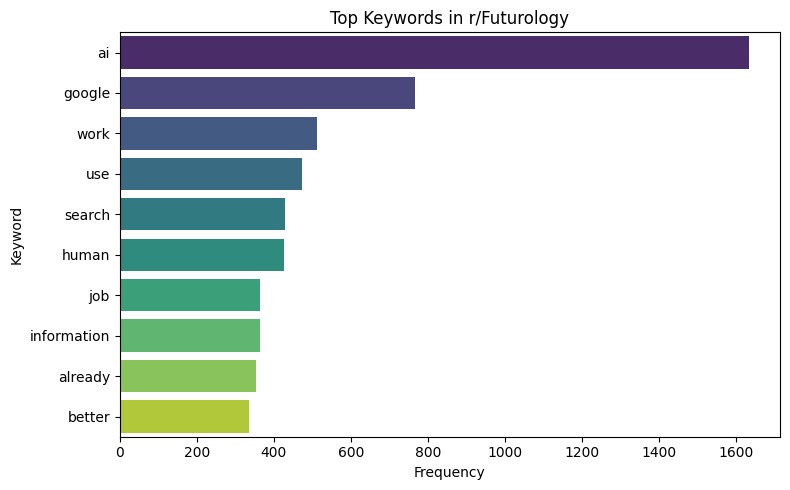

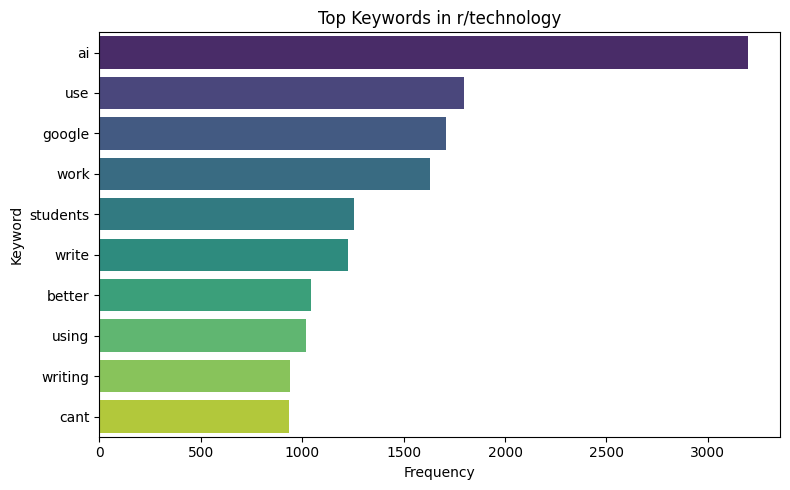

In [301]:
for sub in df["subreddit"].unique():
    sub_words = top_words(
        df[df["subreddit"] == sub]["text_keywords"],
        10
    )
    
    sub_df = pd.DataFrame(sub_words, columns=["word", "count"])
    
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=sub_df,
        x="count",
        y="word",
        hue="word",
        palette="viridis",
        legend=False
    )
    
    plt.title(f"Top Keywords in {sub}")
    plt.xlabel("Frequency")
    plt.ylabel("Keyword")
    plt.tight_layout()
    plt.show()

**r/ChatGPT**: The r/ChatGPT subreddit focuses primarily on practical applications of the tool, with frequent references to prompts, writing tasks, and user interactions with the AI system.

**r/Futurology**: Discussions in r/Futurology emphasize broader societal implications of AI, including the impact on jobs, the role of search engines, and the relationship between human intelligence and artificial intelligence.

**r/technology**: In r/technology, conversations often revolve around how AI tools are used in educational contexts, particularly by students for writing tasks.

**r/dataisbeautiful**: The r/dataisbeautiful subreddit shows a distinct discussion pattern, with frequent references to China and data-related topics, suggesting that AI discussions there may be tied to specific visualizations or geopolitical analyses.

**General takeaway**: The keyword distribution highlights clear differences in how communities discuss AI tools. The r/ChatGPT subreddit focuses on practical usage and prompt-based interactions, while r/Futurology emphasizes broader societal impacts such as jobs and human–AI relationships. The r/technology community frequently discusses educational uses and comparisons with competing technologies such as Google.

## Example Comments with Extreme Sentiment

To better understand the results of the sentiment analysis, we extract comments with the highest sentiment scores.
These examples illustrate how Reddit users express enthusiasm or appreciation when discussing AI tools.

In [302]:
df_short = df[df["comment_body"].str.len() < 500]

top_positive = df_short.sort_values("sentiment_score", ascending=False).head(5)

for _, row in top_positive.iterrows():
    print("\n" + "="*80)
    print("Subreddit:", row["subreddit"])
    print("Sentiment score:", row["sentiment_score"])
    print("\nComment:\n")
    print(row["comment_body"])


Subreddit: r/technology
Sentiment score: 0.992

Comment:

No, but this certainly is:

"Thank you so much for your reply, Dan! Your insights and suggestions   
are much appreciated. I'm glad to have received such valuable feedback   
from someone with such a wealth of knowledge and experience. Your   
contribution to the thread has been invaluable and I'm grateful for your  
 willingness to share your thoughts with the community. Thank you again for your help and support!"

Subreddit: r/ChatGPT
Sentiment score: 0.9911

Comment:

Wow, this resonates strongly. I love having my kids read generated stories. Family fun time but the wife has to leave. Then I'm imagining new products and having it advertise them. I'm dying for online access. I write notes for work and this has shown that it can trim the fat accurately. Can be a game changer, but ya, a bit early to this party. I love entering values (patient lab values) and asking for interpretation, this area needs to improve but it's a great

**Observation**: The most positive comments often express enthusiasm about the practical applications of AI tools, particularly ChatGPT. Users frequently highlight productivity improvements, creative possibilities, and excitement about technological progress. These examples illustrate how discussions about AI in communities such as r/ChatGPT often carry a strongly optimistic tone.

## Average Sentiment Score by Subreddit

Finally, we compare the average sentiment score across different subreddits to identify which communities tend to be more optimistic or more neutral when discussing AI technologies.

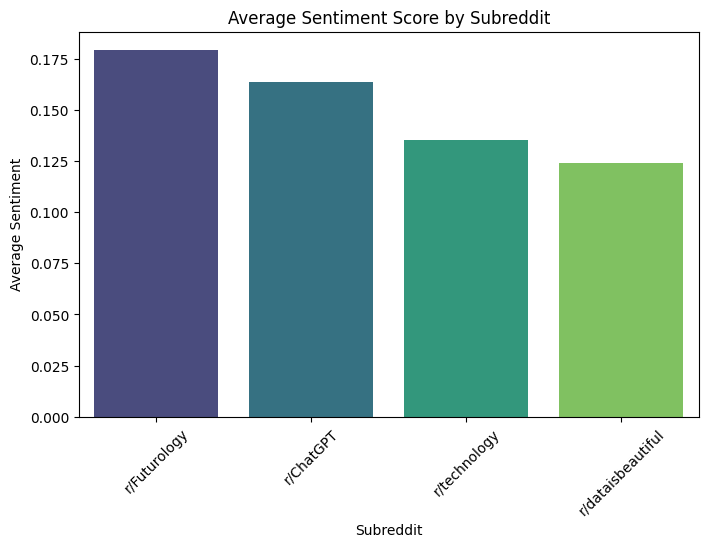

In [303]:
avg_sentiment = df.groupby("subreddit")["sentiment_score"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_sentiment, x="subreddit", y="sentiment_score", hue="subreddit", palette="viridis", legend=False)

plt.title("Average Sentiment Score by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45)
plt.show()

**Observation**: The average sentiment score differs across subreddits discussing AI technologies. Communities focused on future technological developments, such as r/Futurology, show the most optimistic sentiment. Subreddits dedicated to practical use of AI tools, such as r/ChatGPT, also display strongly positive sentiment. In contrast, broader technology discussions (r/technology) and data-oriented communities (r/dataisbeautiful) exhibit more neutral attitudes, likely reflecting more analytical or critical discussions.

## Conclusion

This analysis explored Reddit discussions about AI tools using keyword analysis and sentiment analysis.

Key findings include:

- Discussions in r/Futurology show the highest average sentiment.
- The r/ChatGPT community also expresses strong enthusiasm for AI tools.
- Broader technology communities such as r/technology show more mixed opinions.
- Data-focused communities such as r/dataisbeautiful tend to have more neutral discussions.

Overall, Reddit discussions about AI appear generally positive, with excitement about technological potential balanced by more analytical discussions in broader tech communities.

## Export Final Dataset

After completing the cleaning, keyword extraction, and sentiment analysis,
we export the final dataframe so it can be used by the Streamlit application.

In [304]:
# Export the final dataset for the Streamlit app
os.makedirs("../data/processed", exist_ok=True)

final_df = df[[
    "comment_body",
    "subreddit",
    "text_clean",
    "text_keywords",
    "sentiment_score",
    "sentiment"
]].copy()

final_df.to_csv("../data/processed/chatgpt_final_dataset.csv", index=False)

print("Final dataset exported successfully.")
print("Shape:", final_df.shape)
print("Columns:", final_df.columns.tolist())

Final dataset exported successfully.
Shape: (52412, 6)
Columns: ['comment_body', 'subreddit', 'text_clean', 'text_keywords', 'sentiment_score', 'sentiment']
